# MecâniQA — Entregável 1: Compreensão e Baseline

**Disciplina:** Modelos de Aprendizado de Máquina
**Time:** Boa-vista
**Membros:** Alex Oliveira Santos, Alice Gomes Aragão, Ana Clara Ribeiro da Silva, Lorran Edley Matos Ribeiro, Rodrigo dos Anjos Lamartine
**Data de entrega:** 29/08/2026

## Contexto

A MecâniQA (oficinas e auto centers de Feira de Santana e região) enfrenta picos inesperados de demanda de manutenção preventiva, gerando falta de peças em alguns dias e ociosidade da equipe de mecânicos em outros.

Como time de Ciência de Dados, nosso papel neste primeiro desafio é construir o **módulo fundacional de análise**: limpar e entender a série temporal histórica de duas frentes do negócio — **Trocas de Óleo** e **Manutenção de Motor** — e criar o primeiro motor de previsão **ingênuo (Baseline)**, que servirá como piso de comparação para os modelos de Machine Learning das próximas sprints.

## Objetivos desta sprint

1. Compreender a estrutura de dados temporais e indexação por tempo.
2. Executar uma Análise Exploratória de Dados (EDA) específica para séries temporais, identificando **Tendência**, **Sazonalidade** e **Ruído**.
3. Tratar dados ausentes e outliers.
4. Implementar e documentar os modelos Baseline: **Naive** e **Médias Móveis**.


## 1. Importação das bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_absolute_error, mean_squared_error

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (14, 6)


## 2. Carregamento e indexação temporal

O primeiro passo para trabalhar com séries temporais é garantir que a coluna de data vire o **índice** do DataFrame, que os registros estejam **ordenados cronologicamente** e que a série tenha frequência diária explícita (`asfreq("D")`). Antes de completar a frequência, preservamos as datas originais para conseguir identificar corretamente eventuais **dias inteiros sem registro**.

In [2]:
df = pd.read_excel("mecaniqa_dataset.xlsx")

df["Data"] = pd.to_datetime(df["Data"])
df = df.set_index("Data")
df = df.sort_index()

# Guardamos as datas originais antes de completar a frequência diária.
datas_originais = df.index.copy()

# Tornamos explícita a frequência diária da série.
df = df.asfreq("D")

df.head()

,Trocas_Oleo,Manutencao_Motor
Data,,
2024-01-01,11.0,2.0
2024-01-02,9.0,4.0
2024-01-03,12.0,1.0
2024-01-04,15.0,8.0
2024-01-05,25.0,10.0


In [3]:
print("Formato do dataset:", df.shape)
print("\nTipos de dado:")
print(df.dtypes)
print("\nPeríodo coberto:", df.index.min().date(), "até", df.index.max().date())


Formato do dataset: (731, 2)

Tipos de dado:
Trocas_Oleo         float64
Manutencao_Motor    float64
dtype: object

Período coberto: 2024-01-01 até 2025-12-31


In [4]:
df.describe()


,Trocas_Oleo,Manutencao_Motor
count,725.000000,728.000000
mean,26.020690,10.179945
std,11.620655,5.419338
min,0.000000,-2.000000
25%,18.000000,7.000000
50%,26.000000,10.000000
75%,33.000000,13.000000
max,150.000000,85.000000


> **Observação:** a média de Trocas de Óleo no período é de aproximadamente 26/dia (desvio padrão ~11,6) e a de Manutenção de Motor é de aproximadamente 10/dia (desvio padrão ~5,4). O valor **mínimo de Manutenção de Motor é negativo**, o que já é um forte indício de erro de digitação — vamos investigar isso na seção de outliers.

## 3. Integridade da linha do tempo (dias sem registro)

Antes de tratar valores nulos, verificamos se existem **dias inteiros sem nenhuma linha no sistema** — isto é, datas que deveriam existir na série, mas que não aparecem no índice original.

In [5]:
print("Valores ausentes por coluna (antes do tratamento):")
print(df.isna().sum())

datas_esperadas = pd.date_range(df.index.min(), df.index.max(), freq="D")
dias_sem_registro = datas_esperadas.difference(datas_originais)

print(f"\nDias sem nenhuma linha no sistema: {len(dias_sem_registro)}")
if len(dias_sem_registro) > 0:
    print(dias_sem_registro)
else:
    print("Nenhum dia inteiro está ausente no índice original.")

Valores ausentes por coluna (antes do tratamento):
Trocas_Oleo         6
Manutencao_Motor    3
dtype: int64

Dias sem nenhuma linha no sistema: 0
Nenhum dia inteiro está ausente no índice original.


**Interpretação:** o dataset possui uma linha para cada um dos **731 dias** do período (2024-01-01 a 2025-12-31), portanto não há dias inteiros faltando. Existem, porém, **6 valores ausentes em Trocas de Óleo e 3 em Manutenção de Motor** dentro de dias que já possuem registro.

## 4. Tratamento de dados ausentes e valores inválidos

Os valores ausentes serão preenchidos por **interpolação baseada em tempo** (`method="time"`), que respeita a ordem cronológica da série. Antes da interpolação, também validamos os valores de domínio: quantidades de serviços não podem ser negativas. Os registros negativos são tratados como **dados inválidos**, convertidos para `NaN` e posteriormente interpolados.

In [6]:
# Valores negativos são impossíveis para quantidades de serviços e indicam erro de lançamento.
for coluna in ["Trocas_Oleo", "Manutencao_Motor"]:
    negativos = df[coluna] < 0
    print(f"{coluna}: {negativos.sum()} valor(es) negativo(s) detectado(s)")
    if negativos.any():
        print(df.loc[negativos, [coluna]])
        df.loc[negativos, coluna] = np.nan

# Interpolação temporal para preencher ausências e os valores inválidos convertidos em NaN.
df["Trocas_Oleo"] = df["Trocas_Oleo"].interpolate(method="time")
df["Manutencao_Motor"] = df["Manutencao_Motor"].interpolate(method="time")

print("\nValores ausentes após tratamento:")
print(df.isna().sum())

Trocas_Oleo: 0 valor(es) negativo(s) detectado(s)
Manutencao_Motor: 5 valor(es) negativo(s) detectado(s)
            Manutencao_Motor
Data                        
2024-09-03              -2.0
2024-09-04              -1.0
2024-09-11              -1.0
2024-09-17              -2.0
2024-09-19              -1.0

Valores ausentes após tratamento:
Trocas_Oleo         0
Manutencao_Motor    0
dtype: int64


## 5. Detecção de outliers (método IQR)

Utilizamos o método do **Intervalo Interquartil (IQR)**: qualquer valor abaixo de `Q1 - 1.5*IQR` ou acima de `Q3 + 1.5*IQR` é considerado um outlier estatístico.

In [7]:
def detectar_outliers_iqr(serie):
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    mascara = (serie < limite_inferior) | (serie > limite_superior)

    return q1, q3, iqr, limite_inferior, limite_superior, mascara


for coluna in ["Trocas_Oleo", "Manutencao_Motor"]:
    q1, q3, iqr, limite_inferior, limite_superior, mascara = detectar_outliers_iqr(df[coluna])

    print(f"\n--- {coluna} ---")
    print(f"Q1: {q1:.2f} | Q3: {q3:.2f} | IQR: {iqr:.2f}")
    print(f"Limite inferior: {limite_inferior:.2f} | Limite superior: {limite_superior:.2f}")
    print(f"Outliers encontrados: {mascara.sum()}")

    if mascara.sum() > 0:
        print(df.loc[mascara, [coluna]])



--- Trocas_Oleo ---
Q1: 18.00 | Q3: 33.00 | IQR: 15.00
Limite inferior: -4.50 | Limite superior: 55.50
Outliers encontrados: 1
            Trocas_Oleo
Data                   
2024-02-15        150.0

--- Manutencao_Motor ---
Q1: 7.00 | Q3: 13.00 | IQR: 6.00
Limite inferior: -2.00 | Limite superior: 22.00
Outliers encontrados: 2
            Manutencao_Motor
Data                        
2024-07-19              85.0
2025-05-03              24.0


**Interpretação dos outliers encontrados:**

- **Trocas de Óleo:** o dia **15/02/2024** registra **150 trocas de óleo**, muito acima do padrão da série (~26/dia), caracterizando um outlier estatístico e um possível erro de digitação.
- **Manutenção de Motor:** foram identificados **85 serviços em 19/07/2024** e **24 em 03/05/2025** como outliers pelo IQR. Além disso, havia **5 valores negativos** (03/09, 04/09, 11/09, 17/09 e 19/09/2024), tratados anteriormente como dados inválidos e interpolados.

Esses pontos poderiam distorcer a análise e os modelos se permanecessem sem tratamento.

## 6. Tratamento de outliers

Optamos por **normalizar (clipping)** os outliers estatísticos para os limites do IQR, em vez de removê-los. Isso preserva a continuidade da série temporal, essencial para os modelos baseline. Para quantidades de serviços, também garantimos um limite inferior de zero.

In [8]:
df_model = df.copy()

for coluna in ["Trocas_Oleo", "Manutencao_Motor"]:
    q1, q3, iqr, limite_inferior, limite_superior, mascara = detectar_outliers_iqr(df_model[coluna])
    limite_inferior = max(0, limite_inferior)

    print(f"{coluna}: {mascara.sum()} outlier(es) estatístico(s) tratado(s)")
    df_model[coluna] = df_model[coluna].clip(lower=limite_inferior, upper=limite_superior)

print("\nEstatísticas após limpeza e tratamento:")
df_model.describe()

Trocas_Oleo: 1 outlier(es) estatístico(s) tratado(s)
Manutencao_Motor: 2 outlier(es) estatístico(s) tratado(s)

Estatísticas após limpeza e tratamento:


,Trocas_Oleo,Manutencao_Motor
count,731.000000,731.000000
mean,25.878933,10.107387
std,10.681153,4.600210
min,0.000000,0.000000
25%,18.000000,7.000000
50%,26.000000,10.000000
75%,33.000000,13.000000
max,55.500000,22.000000


## 7. EDA Visual — Série temporal completa

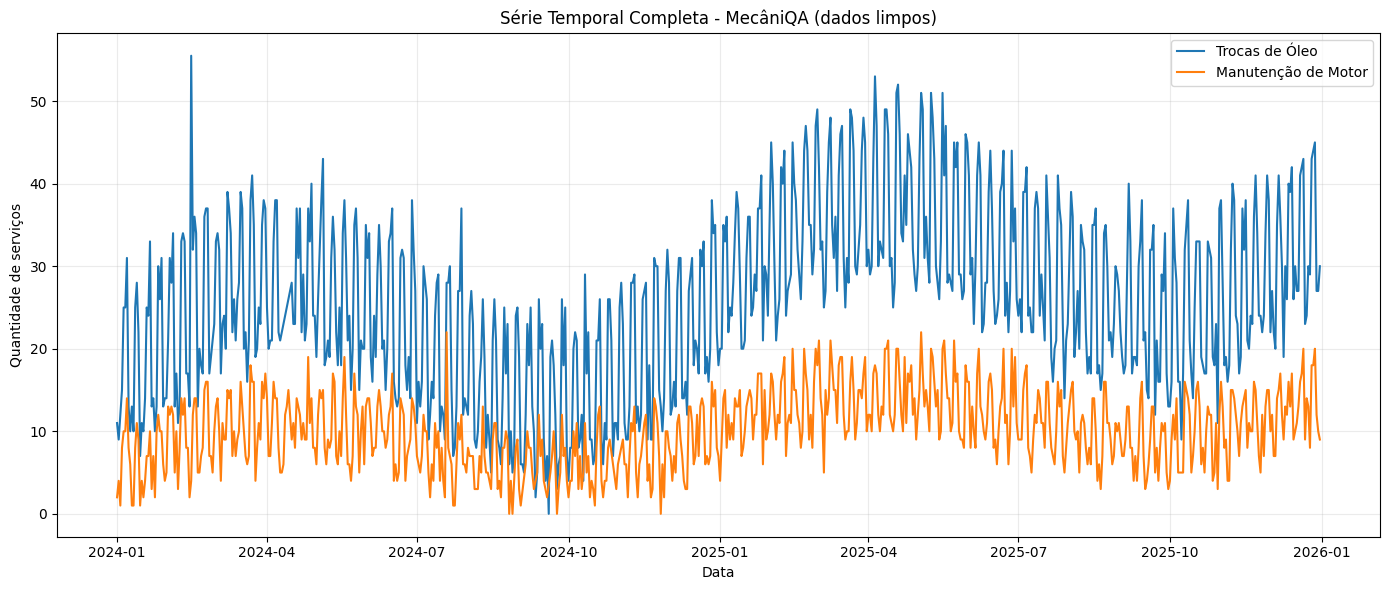

In [9]:
plt.figure(figsize=(14, 6))
plt.plot(df_model.index, df_model["Trocas_Oleo"], label="Trocas de Óleo")
plt.plot(df_model.index, df_model["Manutencao_Motor"], label="Manutenção de Motor")
plt.title("Série Temporal Completa - MecâniQA (dados limpos)")
plt.xlabel("Data")
plt.ylabel("Quantidade de serviços")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


**Interpretação:** já é possível notar visualmente dois padrões: (1) um crescimento gradual do volume de serviços ao longo dos dois anos, e (2) uma oscilação recorrente dentro de cada mês/semana. Vamos separar formalmente esses componentes na decomposição a seguir.

## 8. Decomposição da série temporal

Usamos `seasonal_decompose` (modelo aditivo) para separar cada série em três componentes:
- **Tendência**: o crescimento (ou queda) estrutural da oficina ao longo do tempo.
- **Sazonalidade**: o padrão que se repete em ciclos fixos — aqui usamos período **7** (semanal), pois a demanda de uma oficina tende a variar conforme o dia da semana.
- **Ruído (resíduo)**: a variação aleatória que sobra depois de remover tendência e sazonalidade.

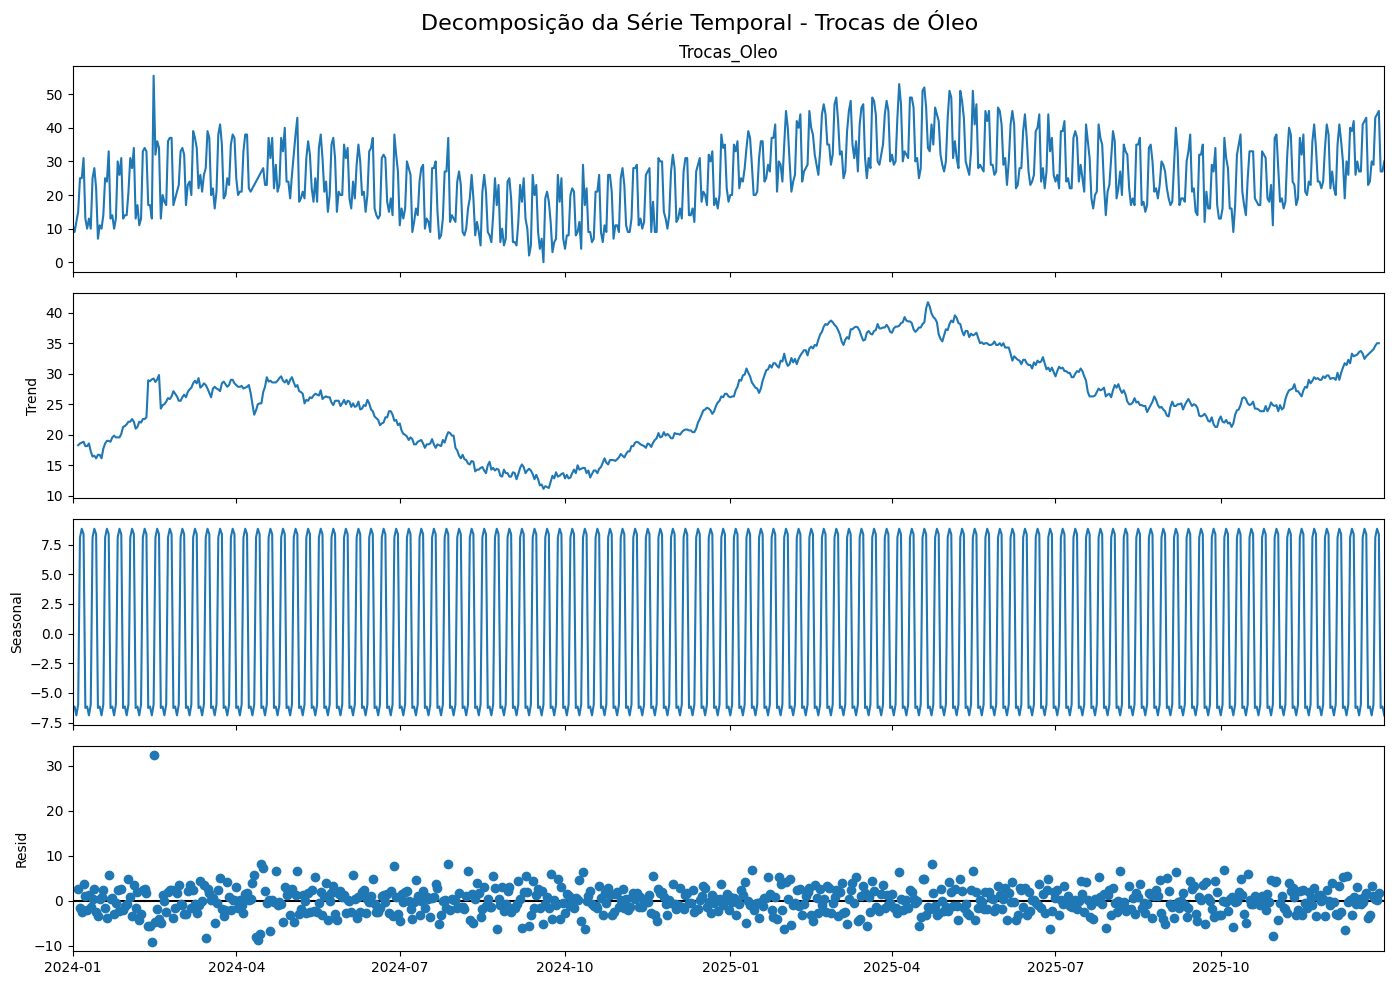

In [10]:
resultado_decomposicao_oleo = seasonal_decompose(
    df_model["Trocas_Oleo"], model="additive", period=7
)

fig = resultado_decomposicao_oleo.plot()
fig.set_size_inches(14, 10)
fig.suptitle("Decomposição da Série Temporal - Trocas de Óleo", fontsize=16)
plt.tight_layout()
plt.show()


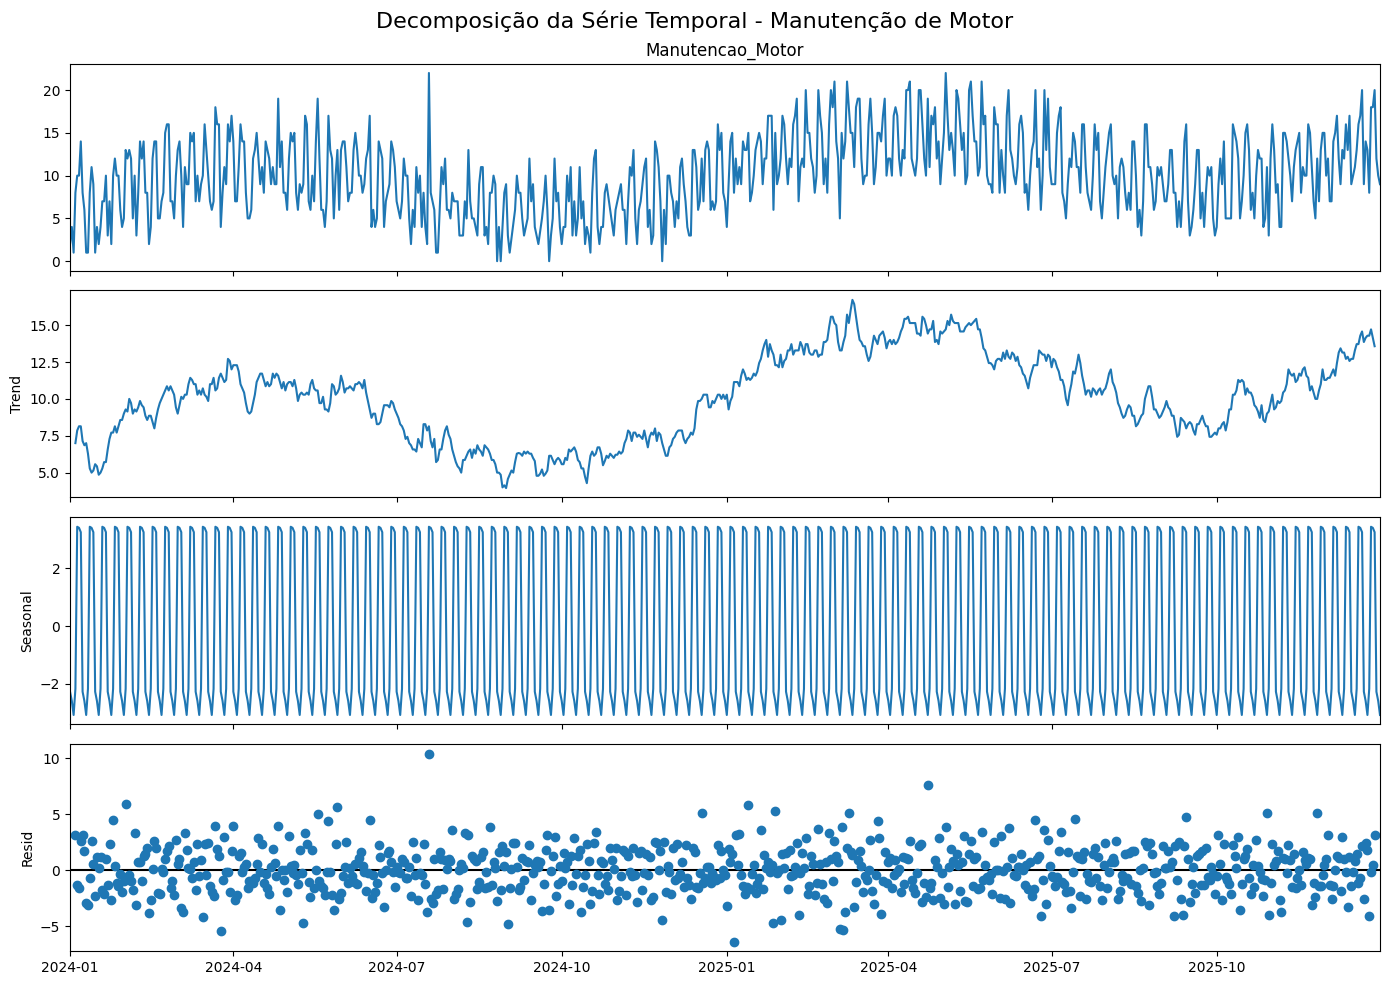

In [11]:
resultado_decomposicao_motor = seasonal_decompose(
    df_model["Manutencao_Motor"], model="additive", period=7
)

fig = resultado_decomposicao_motor.plot()
fig.set_size_inches(14, 10)
fig.suptitle("Decomposição da Série Temporal - Manutenção de Motor", fontsize=16)
plt.tight_layout()
plt.show()


In [12]:
medias_por_dia_semana = df_model.groupby(df_model.index.dayofweek)[["Trocas_Oleo", "Manutencao_Motor"]].mean()
medias_por_dia_semana.index = ["Seg", "Ter", "Qua", "Qui", "Sex", "Sáb", "Dom"]
medias_por_dia_semana


,Trocas_Oleo,Manutencao_Motor
Seg,19.590476,7.828571
Ter,19.714286,7.525397
Qua,19.066667,7.022222
Qui,19.899038,7.947115
Sex,34.000000,13.567308
Sáb,34.750000,13.538462
Dom,34.317308,13.399038


**Interpretação da decomposição:**

- **Tendência:** a média de Trocas de Óleo sobe de aproximadamente **18/dia** no início da série para **32/dia** no final (média móvel de 30 dias), e a Manutenção de Motor sobe de **~6/dia** para **~13/dia** — um crescimento de praticamente **80–110%** ao longo dos dois anos. Isso confirma a leitura do enunciado: a oficina está crescendo estruturalmente, não é só ruído.
- **Sazonalidade:** ao agrupar por dia da semana, fica claro um padrão semanal forte — de segunda a quinta a demanda fica em torno de **19–20** trocas de óleo e **7–8** manutenções, mas de **sexta a domingo** ela salta para **~34** trocas e **~13–14** manutenções. Ou seja, o fim de semana concentra quase o dobro da demanda dos dias úteis — provavelmente porque os clientes preferem levar o carro para manutenção quando não estão trabalhando.
- **Ruído:** o componente residual da decomposição mostra flutuações menores e sem padrão aparente em torno de zero, condizentes com variações do dia a dia (clima, fluxo aleatório de clientes) que não seguem tendência nem sazonalidade.

## 9. Modelos Baseline

### 9.1 Modelo Naive (Ingênuo)

Prevê que a demanda de amanhã será **exatamente igual à demanda de hoje** — o piso mínimo de comparação para qualquer modelo mais sofisticado.

In [13]:
def modelo_naive(serie):
    return serie.shift(1)


### 9.2 Modelo de Médias Móveis

Prevê o próximo dia como a **média das últimas N observações** (7 e 30 dias). Usamos `shift(1)` antes do `rolling` para garantir que a previsão do dia *t* use apenas dados **até o dia *t-1*** — sem isso, o modelo "veria o futuro" (vazamento de dados).

In [14]:
def modelo_media_movel(serie, janela):
    return serie.shift(1).rolling(window=janela).mean()


### 9.3 Separação treino/teste

Reservamos os **últimos 30 dias** da série como conjunto de teste. Como é uma série temporal, o split é **cronológico** (não aleatório) — treinar com dados do futuro para prever o passado não faria sentido no mundo real.

In [15]:
quantidade_teste = 30

treino = df_model.iloc[:-quantidade_teste]
teste = df_model.iloc[-quantidade_teste:]

print(f"Treino: {treino.shape[0]} dias | Teste: {teste.shape[0]} dias")


Treino: 701 dias | Teste: 30 dias


In [16]:
previsao_naive_oleo = modelo_naive(df_model["Trocas_Oleo"])
previsao_media_7_oleo = modelo_media_movel(df_model["Trocas_Oleo"], 7)
previsao_media_30_oleo = modelo_media_movel(df_model["Trocas_Oleo"], 30)

previsao_naive_motor = modelo_naive(df_model["Manutencao_Motor"])
previsao_media_7_motor = modelo_media_movel(df_model["Manutencao_Motor"], 7)
previsao_media_30_motor = modelo_media_movel(df_model["Manutencao_Motor"], 30)


### 9.4 Avaliação dos modelos (MAE e RMSE)

In [17]:
def avaliar_modelo(real, previsao):
    previsao = previsao.loc[real.index]
    mascara = previsao.notna()

    real = real[mascara]
    previsao = previsao[mascara]

    mae = mean_absolute_error(real, previsao)
    rmse = np.sqrt(mean_squared_error(real, previsao))

    return mae, rmse


resultados_baseline = []

modelos_oleo = {
    "Naive": previsao_naive_oleo,
    "Média Móvel 7 dias": previsao_media_7_oleo,
    "Média Móvel 30 dias": previsao_media_30_oleo,
}

for nome, previsao in modelos_oleo.items():
    mae, rmse = avaliar_modelo(teste["Trocas_Oleo"], previsao)
    resultados_baseline.append({"Variável": "Trocas_Oleo", "Modelo": nome, "MAE": mae, "RMSE": rmse})

modelos_motor = {
    "Naive": previsao_naive_motor,
    "Média Móvel 7 dias": previsao_media_7_motor,
    "Média Móvel 30 dias": previsao_media_30_motor,
}

for nome, previsao in modelos_motor.items():
    mae, rmse = avaliar_modelo(teste["Manutencao_Motor"], previsao)
    resultados_baseline.append({"Variável": "Manutencao_Motor", "Modelo": nome, "MAE": mae, "RMSE": rmse})

resultados_baseline = pd.DataFrame(resultados_baseline)
resultados_baseline.round(2)


,Variável,Modelo,MAE,RMSE
0,Trocas_Oleo,Naive,6.40,8.73
1,Trocas_Oleo,Média Móvel 7 dias,7.07,7.75
2,Trocas_Oleo,Média Móvel 30 dias,6.67,7.93
3,Manutencao_Motor,Naive,3.50,4.51
4,Manutencao_Motor,Média Móvel 7 dias,3.22,3.73
5,Manutencao_Motor,Média Móvel 30 dias,3.26,3.80


**Interpretação dos resultados:** para **Trocas de Óleo**, o modelo **Naive** apresentou o menor MAE (**6,40**), enquanto a Média Móvel de 7 dias teve o menor RMSE (**7,75**). Isso mostra que o Naive teve menor erro absoluto médio, mas alguns erros maiores elevaram seu RMSE. Para **Manutenção de Motor**, a **Média Móvel de 7 dias** apresentou o melhor desempenho tanto em MAE (**3,22**) quanto em RMSE (**3,73**). Esses resultados estabelecem o **piso de comparação** para modelos mais avançados nas próximas sprints.

## 10. Real x Previsões — Trocas de Óleo

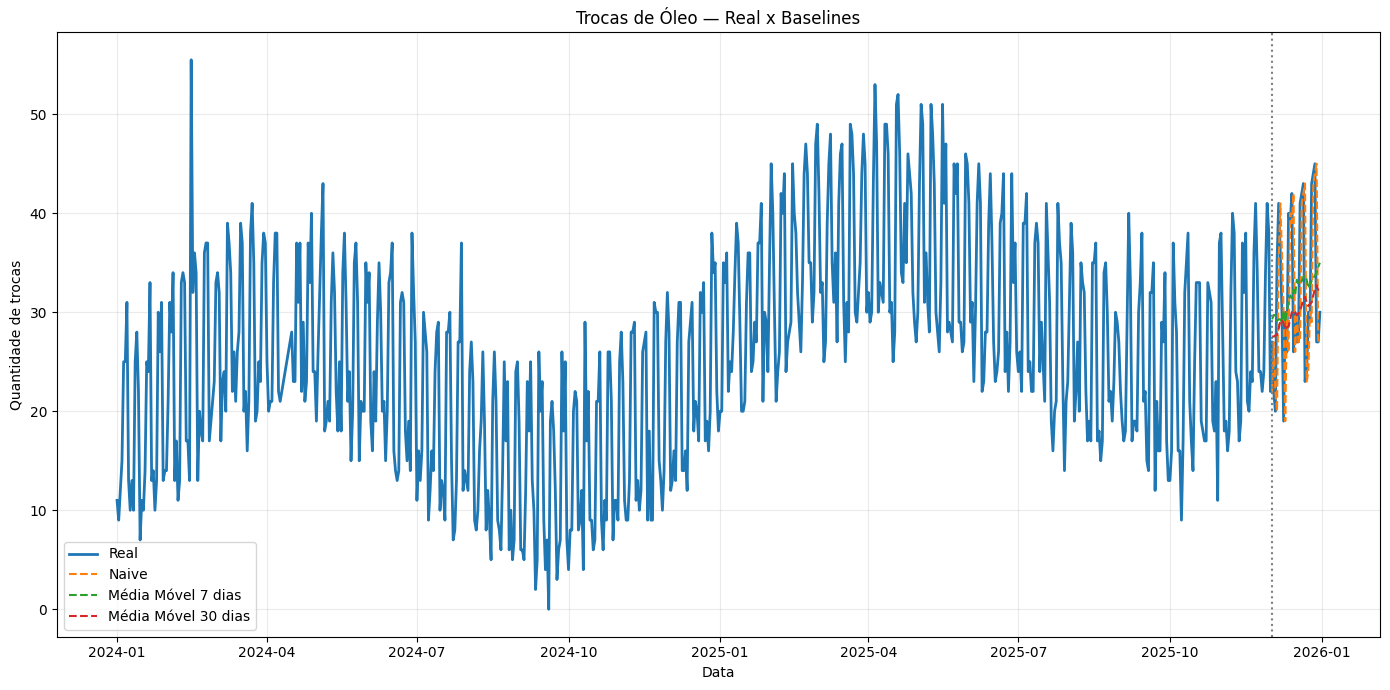

In [18]:
plt.figure(figsize=(14, 7))
plt.plot(df_model.index, df_model["Trocas_Oleo"], label="Real", linewidth=2)
plt.plot(teste.index, previsao_naive_oleo.loc[teste.index], label="Naive", linestyle="--")
plt.plot(teste.index, previsao_media_7_oleo.loc[teste.index], label="Média Móvel 7 dias", linestyle="--")
plt.plot(teste.index, previsao_media_30_oleo.loc[teste.index], label="Média Móvel 30 dias", linestyle="--")
plt.axvline(teste.index[0], linestyle=":", color="gray")
plt.title("Trocas de Óleo — Real x Baselines")
plt.xlabel("Data")
plt.ylabel("Quantidade de trocas")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## 11. Real x Previsões — Manutenção de Motor

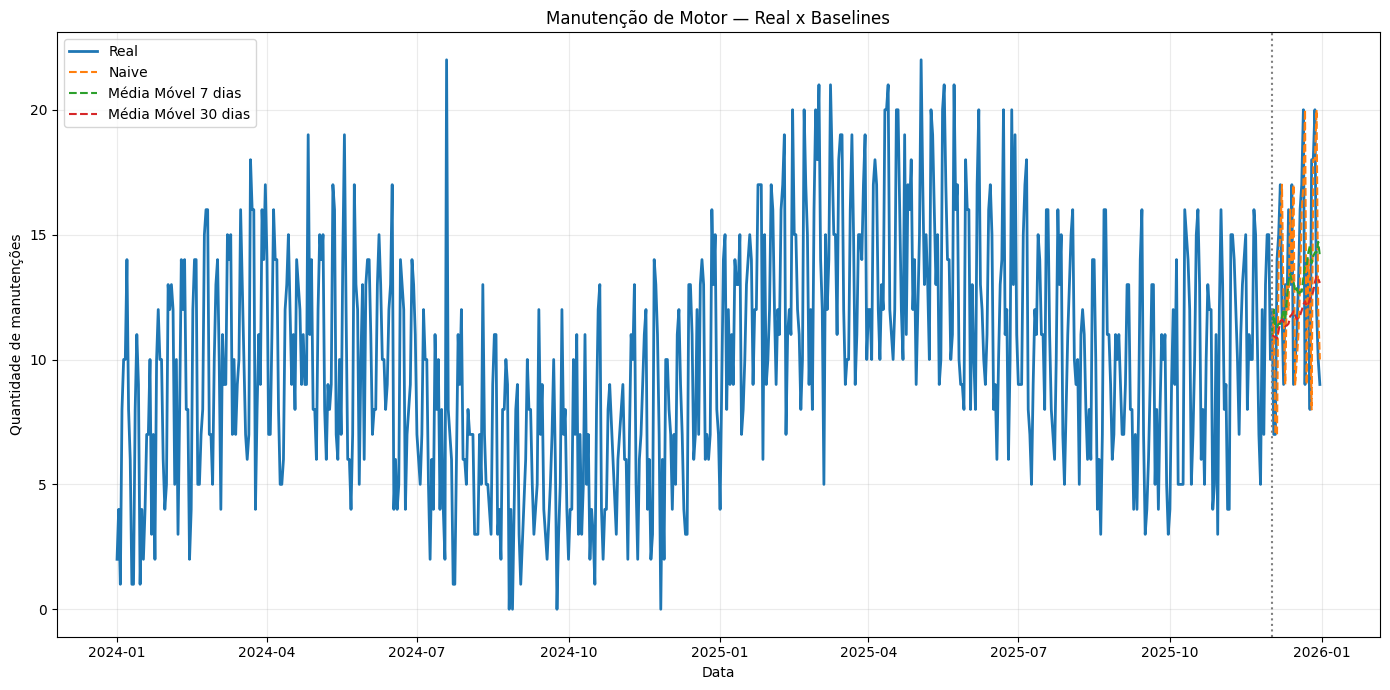

In [19]:
plt.figure(figsize=(14, 7))
plt.plot(df_model.index, df_model["Manutencao_Motor"], label="Real", linewidth=2)
plt.plot(teste.index, previsao_naive_motor.loc[teste.index], label="Naive", linestyle="--")
plt.plot(teste.index, previsao_media_7_motor.loc[teste.index], label="Média Móvel 7 dias", linestyle="--")
plt.plot(teste.index, previsao_media_30_motor.loc[teste.index], label="Média Móvel 30 dias", linestyle="--")
plt.axvline(teste.index[0], linestyle=":", color="gray")
plt.title("Manutenção de Motor — Real x Baselines")
plt.xlabel("Data")
plt.ylabel("Quantidade de manutenções")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## 12. Conclusão e próximos passos

Neste Entregável 1, construímos a base do sistema preditivo da MecâniQA:

- Validamos a integridade da linha do tempo e confirmamos os **731 dias consecutivos** do histórico.
- Tratamos **6 valores ausentes em Trocas de Óleo e 3 em Manutenção de Motor** por interpolação temporal.
- Detectamos e corrigimos **5 valores negativos inválidos** e os outliers estatísticos pelo **IQR**, preservando a continuidade da série.
- Identificamos **tendência de crescimento (~80–110%)** e **sazonalidade semanal**.
- Implementamos os baselines **Naive** e **Médias Móveis de 7 e 30 dias**, avaliados nos últimos 30 dias por MAE e RMSE.

**Próximos passos:** usar esses resultados como referência para avaliar modelos de Machine Learning mais sofisticados nas próximas sprints.